temperature
inside mean  19.534007188813028
outside mean  15.670832622111345
inside std  0.1950088120527288
outside std  1.7532119565097513
Are they different?  True
-------------------
gas
inside mean  184763.32773109243
outside mean  167870.1806722689
inside std  14444.720757651978
outside std  21729.788448624608
Are they different?  True
-------------------
humidity
inside mean  33.568937655100875
outside mean  37.16197291629853
inside std  0.37247716170776635
outside std  2.062995906445026
Are they different?  True
-------------------
pressure
inside mean  1003.2545129139211
outside mean  1003.3078593155382
inside std  0.02020708289200334
outside std  0.2788223550392218
Are they different?  True
-------------------
altitude
inside mean  83.55361419659569
outside mean  83.10616094196526
inside std  0.1695939967399444
outside std  2.340369799935372
Are they different?  True
-------------------
pm10standard
inside mean  0.0
outside mean  0.9789915966386554
inside std  0.0
outside std 

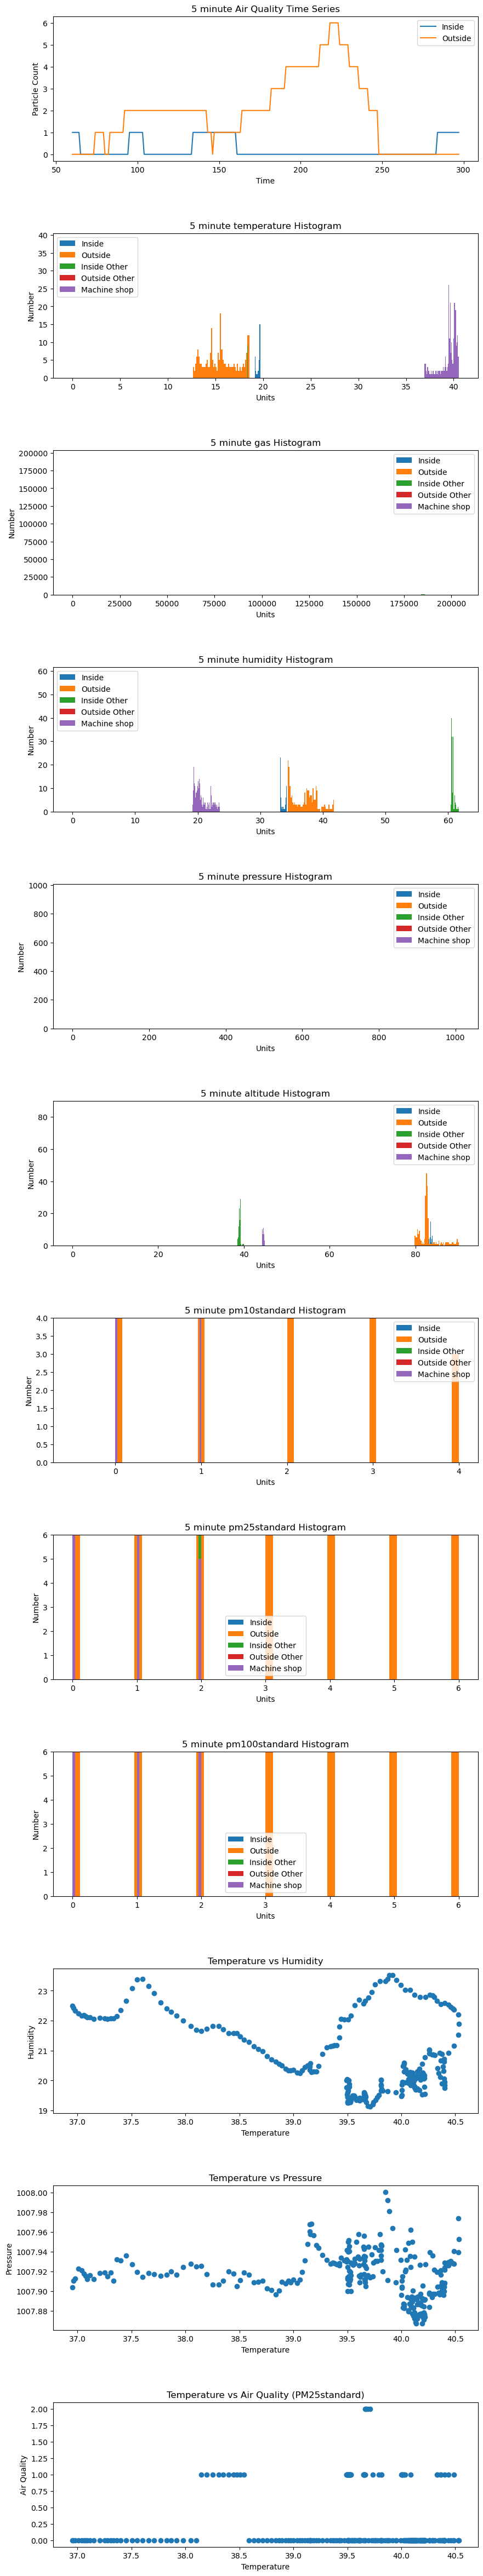

In [53]:
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
import numpy as np

drop_columns = [
    'pm10env',
    'pm25env',
    'pm100 env',
    'p03um',
    'p05um',
    'p10um',
    'p25um',
    'p50um',
    'p100um'
]

# Prepare inside data
data_inside = pd.read_csv('data/inside_5min.csv')
data_inside = data_inside.drop(columns=drop_columns)
data_inside = data_inside.iloc[60:]

# Prepare outside data
data_outside = pd.read_csv('data/double_data_outside_5min.csv')
data_outside = data_outside.drop(columns=drop_columns)
data_outside = data_outside.iloc[60:]

# combine
data = pd.concat([data_inside,data_outside])

# Other group data
# Prepare inside data
data_inside_other = pd.read_csv('data/testindoor.csv')
data_inside_other = data_inside_other.iloc[60:]

# Prepare outside data
data_outside_other = pd.read_csv('data/testoutdoor.csv')
data_outside_other = data_outside_other.iloc[60:]

# Machine shop data
data_shop = pd.read_csv('data/machine_shop_data.csv')
data_shop = data_shop.drop(columns=drop_columns)
data_shop = data_shop.iloc[60:]

columns = [
  'temperature',
  'gas',
  'humidity',
  'pressure',
  'altitude',
  'pm10standard',
  'pm25standard',
  'pm100standard'
]

# Inside vs Outside data
for column in columns:
  mean_inside = np.mean(data_inside[column])
  std_inside = np.std(data_inside[column])
  mean_outside = np.mean(data_outside[column])
  std_outside = np.std(data_outside[column])
  std_mean = std_outside / np.sqrt(300)
  isDifferent = np.abs(mean_inside - mean_outside) > (2 * std_mean)
  print(column)
  print('inside mean ', mean_inside)
  print('outside mean ', mean_outside)
  print('inside std ', std_inside)
  print('outside std ', std_outside)
  print('Are they different? ',isDifferent)
  print('-------------------')

# Comparison with other Group inside
for column in columns:
  mean_ours = np.mean(data_inside[column])
  std_ours = np.std(data_inside[column])
  mean_other = np.mean(data_inside_other[column])
  std_other = np.std(data_inside_other[column])
  std_mean = std_other / np.sqrt(300)
  isDifferent = np.abs(mean_ours - mean_other) > (2 * std_mean)
  print(column)
  # print('our mean ', mean_ours)
  # print('other mean ', mean_other)
  # print('our std ', std_ours)
  # print('other std ', std_other)
  # print('Are they different? ',isDifferent)
  # print('-------------------')

# Comparison with other Group outside
for column in columns:
  mean_ours = np.mean(data_outside[column])
  std_ours = np.std(data_outside[column])
  mean_other = np.mean(data_outside_other[column])
  std_other = np.std(data_outside_other[column])
  std_mean = std_other / np.sqrt(300)
  isDifferent = np.abs(mean_ours - mean_other) > (2 * std_mean)
  # print(column)
  # print('our mean ', mean_ours)
  # print('other mean ', mean_other)
  # print('our std ', std_ours)
  # print('other std ', std_other)
  # print('Are they different? ',isDifferent)
  # print('-------------------')

# Machine shop data vs Outside data
for column in columns:
  mean_shop = np.mean(data_shop[column])
  std_shop = np.std(data_shop[column])
  mean_outside = np.mean(data_outside[column])
  std_outside = np.std(data_outside[column])
  std_mean = std_outside / np.sqrt(300)
  isDifferent = np.abs(mean_shop - mean_outside) > (2 * std_mean)
  # print(column)
  # print('inside mean ', mean_inside)
  # print('outside mean ', mean_outside)
  # print('inside std ', std_inside)
  # print('outside std ', std_outside)
  # print('Are they different? ',isDifferent)
  # print('-------------------')

# times = []
# for entry in data_outside['time']:
#     dt = datetime.strptime(entry, '%a %b %d %H:%M:%S %Y')
#     times.append(dt)

fig, ax = plt.subplots(figsize=(10,60),nrows=12)
plt.subplots_adjust(hspace=0.5)
ax[0].plot(data_inside['pm25standard'], label='Inside')
ax[0].plot(data_outside['pm25standard'], label='Outside')

ax[0].legend() 
ax[0].set_xlabel('Time')
ax[0].set_ylabel('Particle Count')
ax[0].set_title('5 minute Air Quality Time Series')

for i, column in enumerate(columns):
    combined = pd.concat([data_inside[column],data_outside[column],data_inside_other[column],data_outside_other[column],data_shop[column]])
    maximum = combined.max()
    ax[i+1].set_ylim(top=maximum)
    ax[i+1].hist(data_inside[column],bins=50, label='Inside')
    ax[i+1].hist(data_outside[column],bins=50, label='Outside')
    ax[i+1].hist(data_inside_other[column],bins=50, label='Inside Other')
    ax[i+1].hist(data_outside_other[column],bins=50, label='Outside Other')
    ax[i+1].hist(data_shop[column],bins=50, label='Machine shop')
    ax[i+1].legend() 
    ax[i+1].set_xlabel('Units')
    ax[i+1].set_ylabel('Number')
    ax[i+1].set_title('5 minute ' + column + ' Histogram')

ax[9].scatter(data_shop['temperature'], data_shop['humidity'])
ax[9].set_xlabel('Temperature')
ax[9].set_ylabel('Humidity')
ax[9].set_title('Temperature vs Humidity')

ax[10].scatter(data_shop['temperature'], data_shop['pressure'])
ax[10].set_xlabel('Temperature')
ax[10].set_ylabel('Pressure')
ax[10].set_title('Temperature vs Pressure')

ax[11].scatter(data_shop['temperature'], data_shop['pm25standard'])
ax[11].set_xlabel('Temperature')
ax[11].set_ylabel('Air Quality')
ax[11].set_title('Temperature vs Air Quality (PM25standard)')

plt.show()

### Lab Activity Questions